# M25CSA037 — Assignment 4: Optimizing Transformer Translation
## English → Hindi | Ray Tune + Optuna Hyperparameter Search

**Pipeline:** Baseline Training → Ray Tune Sweep (Optuna + ASHA) → Best Model Retraining → Side-by-side Comparison

In [1]:
!pip install -q ray[tune] optuna
print("✅ Packages installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.0/73.0 MB 10.9 MB/s eta 0:00:00
✅ Packages installed


In [2]:
import os, math, time, pickle, warnings, json
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from tqdm import tqdm

import nltk
nltk.download('punkt', quiet=True)
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

import ray
from ray import tune
from ray.tune.search.optuna import OptunaSearch
from ray.tune.schedulers import ASHAScheduler

# ── Style ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor" : "#0f0f0f",
    "axes.facecolor"   : "#1a1a2e",
    "axes.edgecolor"   : "#444",
    "axes.labelcolor"  : "#e0e0e0",
    "xtick.color"      : "#aaa",
    "ytick.color"      : "#aaa",
    "text.color"       : "#e0e0e0",
    "grid.color"       : "#333",
    "grid.linestyle"   : "--",
    "grid.alpha"       : 0.5,
    "legend.facecolor" : "#1a1a2e",
    "legend.edgecolor" : "#444",
    "font.size"        : 11,
})
BASELINE_COLOR = "#e05252"
TUNED_COLOR    = "#52b4e0"
ACCENT_COLOR   = "#f0b429"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch : {torch.__version__}")
print(f"Ray     : {ray.__version__}")
print(f"Device  : {DEVICE}")
print("✅ All imports successful")

PyTorch : 2.10.0+cu128
Ray     : 2.54.0
Device  : cuda
✅ All imports successful


---
## 📦 Section 1 — Data Loading & Preprocessing

In [3]:
df = pd.read_csv('/content/English-Hindi - English-Hindi.tsv', sep='\t', header=None, names=["id1","en","id2","hi"])
df = df[["en","hi"]]
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

# ── Use only 30% of the dataset ───────────────────────────────────────────────
df = df.sample(frac=0.30, random_state=42).reset_index(drop=True)
print(f"Using 30% subset : {len(df)} sentence pairs")

df["en_len"] = df["en"].apply(lambda x: len(x.split()))
df["hi_len"] = df["hi"].apply(lambda x: len(x.split()))

print(f"Total sentence pairs : {len(df)}")
df.head()

Using 30% subset : 3956 sentence pairs
Total sentence pairs : 3956


,en,hi,en_len,hi_len
0,I owe what I am to my friend.,मैं जो भी हूँ मेरे दोस्त की वजह से हूँ।,8,10
1,They must have made a mistake.,उनसे ग़लती हो गई होगी।,6,5
2,They can't see Tom.,वे टॉम को नहीं देख सकते।,4,6
3,"This is an apple, too.",यह भी सेव है।,5,4
4,Keep listening.,सुनते रहो।,2,2


In [4]:
df.head(5)

,en,hi,en_len,hi_len
0,I owe what I am to my friend.,मैं जो भी हूँ मेरे दोस्त की वजह से हूँ।,8,10
1,They must have made a mistake.,उनसे ग़लती हो गई होगी।,6,5
2,They can't see Tom.,वे टॉम को नहीं देख सकते।,4,6
3,"This is an apple, too.",यह भी सेव है।,5,4
4,Keep listening.,सुनते रहो।,2,2


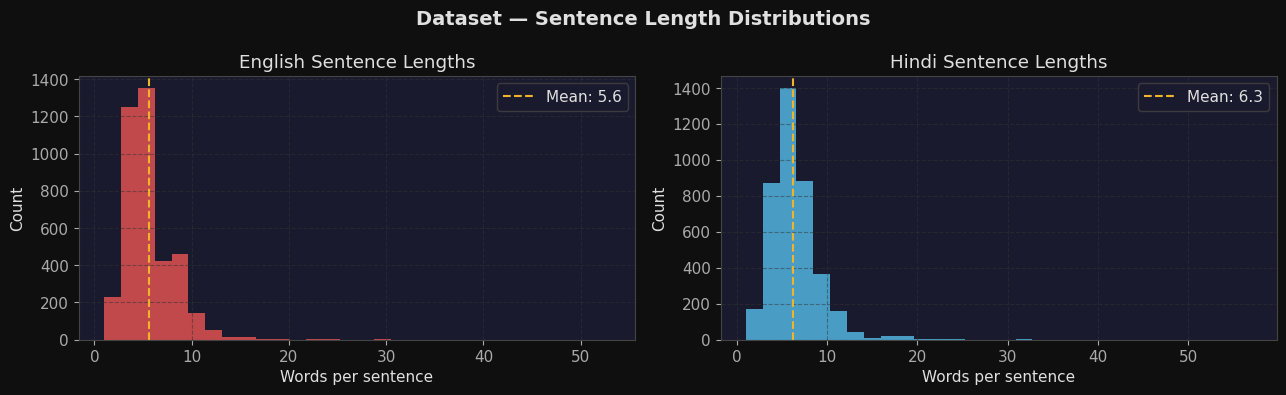

✅ EDA plot saved


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Dataset — Sentence Length Distributions", fontsize=14, fontweight="bold")

for ax, col, lang, color in zip(axes,
        ["en_len","hi_len"], ["English","Hindi"],
        [BASELINE_COLOR, TUNED_COLOR]):
    ax.hist(df[col], bins=30, color=color, edgecolor="none", alpha=0.85)
    ax.axvline(df[col].mean(), color=ACCENT_COLOR, linestyle="--", linewidth=1.5,
               label=f"Mean: {df[col].mean():.1f}")
    ax.set_title(f"{lang} Sentence Lengths")
    ax.set_xlabel("Words per sentence")
    ax.set_ylabel("Count")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.savefig("plot_dataset_eda.png", dpi=130, bbox_inches="tight")
plt.show()
print("✅ EDA plot saved")

---
## 📚 Section 2 — Vocabulary, Tokenisation & Model Architecture

In [6]:
class Vocabulary:
    def __init__(self, freq_threshold=2):
        self.freq_threshold = freq_threshold
        self.itos = {0:"<pad>",1:"<sos>",2:"<eos>",3:"<unk>"}
        self.stoi = {"<pad>":0,"<sos>":1,"<eos>":2,"<unk>":3}
        self.idx = 4

    def build_vocab(self, sentence_list):
        frequencies = Counter()
        for s in sentence_list:
            for w in s.lower().strip().split():
                frequencies[w] += 1
        for word, freq in frequencies.items():
            if freq >= self.freq_threshold:
                self.stoi[word] = self.idx
                self.itos[self.idx] = word
                self.idx += 1

    def numericalize(self, sentence):
        return [self.stoi.get(w, self.stoi["<unk>"]) for w in sentence.lower().strip().split()]

    def __len__(self):   return len(self.stoi)
    def __getitem__(self, token): return self.stoi.get(token, self.stoi["<unk>"])


def encode_sentence(sentence, vocab, max_len=50):
    tokens = ([vocab.stoi["<sos>"]]
              + vocab.numericalize(sentence)[:max_len-2]
              + [vocab.stoi["<eos>"]])
    return tokens + [vocab.stoi["<pad>"]] * (max_len - len(tokens))


en_vocab = Vocabulary(freq_threshold=2)
hi_vocab = Vocabulary(freq_threshold=2)
en_vocab.build_vocab(df["en"].tolist())
hi_vocab.build_vocab(df["hi"].tolist())

MAX_LEN     = 50
D_MODEL     = 512
SRC_PAD_IDX = en_vocab["<pad>"]
TGT_PAD_IDX = hi_vocab["<pad>"]

print(f"English vocab : {len(en_vocab):,} tokens")
print(f"Hindi   vocab : {len(hi_vocab):,} tokens")

English vocab : 1,712 tokens
Hindi   vocab : 1,782 tokens


In [7]:
# ── Full Transformer architecture ────────────────────────────────────────────

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0,d_model,2).float() * (-math.log(10000.0)/d_model))
        pe[:,0::2] = torch.sin(pos*div);  pe[:,1::2] = torch.cos(pos*div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self,x): return x + self.pe[:,:x.size(1)]


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_model, self.num_heads = d_model, num_heads
        self.d_k = d_model // num_heads
        self.Wq = nn.Linear(d_model,d_model)
        self.Wk = nn.Linear(d_model,d_model)
        self.Wv = nn.Linear(d_model,d_model)
        self.Wo = nn.Linear(d_model,d_model)
        self.drop = nn.Dropout(0.1)
    def forward(self,q,k,v,mask=None):
        B=q.size(0)
        def proj(x,W): return W(x).view(B,-1,self.num_heads,self.d_k).transpose(1,2)
        Q,K,V = proj(q,self.Wq),proj(k,self.Wk),proj(v,self.Wv)
        s = torch.matmul(Q,K.transpose(-2,-1))/(self.d_k**0.5)
        if mask is not None: s = s.masked_fill(mask==0,-1e9)
        a = self.drop(torch.softmax(s,dim=-1))
        return self.Wo(torch.matmul(a,V).transpose(1,2).contiguous().view(B,-1,self.d_model))


class FeedForward(nn.Module):
    def __init__(self,d_model,d_ff=2048,dropout=0.1):
        super().__init__()
        self.net=nn.Sequential(nn.Linear(d_model,d_ff),nn.ReLU(),
                               nn.Dropout(dropout),nn.Linear(d_ff,d_model))
    def forward(self,x): return self.net(x)


class LayerNorm(nn.Module):
    def __init__(self,d_model,eps=1e-6):
        super().__init__()
        self.g=nn.Parameter(torch.ones(d_model)); self.b=nn.Parameter(torch.zeros(d_model)); self.eps=eps
    def forward(self,x):
        m,s=x.mean(-1,keepdim=True),x.std(-1,keepdim=True)
        return self.g*(x-m)/(s+self.eps)+self.b


class EncoderLayer(nn.Module):
    def __init__(self,d_model,num_heads,d_ff,dropout=0.1):
        super().__init__()
        self.attn=MultiHeadAttention(d_model,num_heads)
        self.ffn=FeedForward(d_model,d_ff,dropout)
        self.n1=LayerNorm(d_model); self.n2=LayerNorm(d_model)
        self.drop=nn.Dropout(dropout)
    def forward(self,x,mask=None):
        x=self.n1(x+self.drop(self.attn(x,x,x,mask)))
        return self.n2(x+self.drop(self.ffn(x)))


class DecoderLayer(nn.Module):
    def __init__(self,d_model,num_heads,d_ff,dropout=0.1):
        super().__init__()
        self.sa=MultiHeadAttention(d_model,num_heads)
        self.ca=MultiHeadAttention(d_model,num_heads)
        self.ffn=FeedForward(d_model,d_ff,dropout)
        self.n1=LayerNorm(d_model); self.n2=LayerNorm(d_model); self.n3=LayerNorm(d_model)
        self.drop=nn.Dropout(dropout)
    def forward(self,x,enc,sm=None,tm=None):
        x=self.n1(x+self.drop(self.sa(x,x,x,tm)))
        x=self.n2(x+self.drop(self.ca(x,enc,enc,sm)))
        return self.n3(x+self.drop(self.ffn(x)))


class Encoder(nn.Module):
    def __init__(self,vsz,d_model,nlayers,nheads,d_ff,max_len,dropout=0.1):
        super().__init__()
        self.emb=nn.Embedding(vsz,d_model); self.pe=PositionalEncoding(d_model,max_len)
        self.layers=nn.ModuleList([EncoderLayer(d_model,nheads,d_ff,dropout) for _ in range(nlayers)])
        self.drop=nn.Dropout(dropout)
    def forward(self,x,mask=None):
        x=self.drop(self.pe(self.emb(x)))
        for l in self.layers: x=l(x,mask)
        return x


class Decoder(nn.Module):
    def __init__(self,vsz,d_model,nlayers,nheads,d_ff,max_len,dropout=0.1):
        super().__init__()
        self.emb=nn.Embedding(vsz,d_model); self.pe=PositionalEncoding(d_model,max_len)
        self.layers=nn.ModuleList([DecoderLayer(d_model,nheads,d_ff,dropout) for _ in range(nlayers)])
        self.drop=nn.Dropout(dropout)
    def forward(self,x,enc,sm=None,tm=None):
        x=self.drop(self.pe(self.emb(x)))
        for l in self.layers: x=l(x,enc,sm,tm)
        return x


class Transformer(nn.Module):
    def __init__(self,src_vsz,tgt_vsz,d_model=512,nlayers=6,nheads=8,d_ff=2048,max_len=100,dropout=0.1):
        super().__init__()
        self.enc=Encoder(src_vsz,d_model,nlayers,nheads,d_ff,max_len,dropout)
        self.dec=Decoder(tgt_vsz,d_model,nlayers,nheads,d_ff,max_len,dropout)
        self.fc=nn.Linear(d_model,tgt_vsz)
    def pad_mask(self,seq,pad): return (seq!=pad).unsqueeze(1).unsqueeze(2)
    def sub_mask(self,sz): return torch.tril(torch.ones(sz,sz)).bool().to(next(self.parameters()).device)
    def forward(self,src,tgt,sp,tp):
        sm=self.pad_mask(src,sp)
        tm=self.pad_mask(tgt,tp) & self.sub_mask(tgt.size(1))
        return self.fc(self.dec(tgt,self.enc(src,sm),sm,tm))


print("✅ Transformer architecture defined")

✅ Transformer architecture defined


In [8]:
class TranslationDataset(Dataset):
    def __init__(self,df,en_vocab,hi_vocab,max_len=50):
        self.en=df["en"].tolist(); self.hi=df["hi"].tolist()
        self.ev=en_vocab; self.hv=hi_vocab; self.ml=max_len
    def __len__(self): return len(self.en)
    def __getitem__(self,i):
        return torch.tensor(encode_sentence(self.en[i],self.ev,self.ml)),                torch.tensor(encode_sentence(self.hi[i],self.hv,self.ml))

def collate_fn(batch):
    s,t=zip(*batch); s=torch.stack(s); t=torch.stack(t)
    return s, t[:,:-1], t[:,1:]

def translate_sentence(model, sentence, max_len=50):
    model.eval()
    src = torch.tensor(encode_sentence(sentence, en_vocab, max_len)).unsqueeze(0).to(DEVICE)
    tgt_tokens = [hi_vocab["<sos>"]]
    for _ in range(max_len):
        tgt = torch.tensor(tgt_tokens).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            out = model(src, tgt, SRC_PAD_IDX, TGT_PAD_IDX)
        nxt = out[0,-1].argmax().item()
        tgt_tokens.append(nxt)
        if nxt == hi_vocab["<eos>"]: break
    return ' '.join([hi_vocab.itos[i] for i in tgt_tokens[1:-1]])

smoothie = SmoothingFunction().method4

val_dataset = [
    ("I love you.",                 "मैं तुमसे प्यार करता हूँ।"),
    ("How are you?",                "आप कैसे हैं?"),
    ("You should sleep.",           "आपको सोना चाहिए।"),
    ("Maybe Tom doesn't love you.", "टॉम शायद तुमसे प्यार नहीं करता है।"),
    ("Let me tell Tom.",            "मुझे टॉम को बताने दीजिए।"),
]

def evaluate_bleu(model):
    refs, hyps = [], []
    for en_s, hi_s in val_dataset:
        pred = translate_sentence(model, en_s)
        hyps.append(pred.split())
        refs.append([hi_s.split()])
    score = corpus_bleu(refs, hyps, smoothing_function=smoothie)
    return score

print("✅ Dataset, DataLoader, translate & BLEU helpers ready")

✅ Dataset, DataLoader, translate & BLEU helpers ready


---
## 🔵 Section 3 — Baseline Training (100 Epochs, Hardcoded Hyperparameters)

Running the original notebook configuration **without any changes**.  
Metrics recorded here form the benchmark for the tuned model.

| Hyperparameter | Baseline Value |
|---|---|
| Learning Rate | 1e-4 |
| Batch Size | 60 |
| num_heads | 8 |
| d_ff | 2048 |
| dropout | 0.1 |
| num_layers | 6 |
| Epochs | 100 |

In [9]:
# ── Baseline hyperparameters (UNCHANGED from original en_to_hi.ipynb) ────────
BASELINE_BATCH   = 60
BASELINE_LR      = 1e-4
BASELINE_HEADS   = 8
BASELINE_DFF     = 2048
BASELINE_DROP    = 0.1
BASELINE_LAYERS  = 6
BASELINE_EPOCHS  = 100

baseline_loader = DataLoader(
    TranslationDataset(df, en_vocab, hi_vocab, MAX_LEN),
    batch_size=BASELINE_BATCH, shuffle=True, collate_fn=collate_fn
)

baseline_model = Transformer(
    src_vsz=len(en_vocab), tgt_vsz=len(hi_vocab),
    d_model=D_MODEL, nlayers=BASELINE_LAYERS, nheads=BASELINE_HEADS,
    d_ff=BASELINE_DFF, max_len=MAX_LEN, dropout=BASELINE_DROP
).to(DEVICE)

baseline_crit = nn.CrossEntropyLoss(ignore_index=TGT_PAD_IDX)
baseline_opt  = optim.Adam(baseline_model.parameters(), lr=BASELINE_LR)

print(f"Baseline model params: {sum(p.numel() for p in baseline_model.parameters()):,}")
print(f"Training for {BASELINE_EPOCHS} epochs on {DEVICE} ...")

Baseline model params: 46,841,590
Training for 100 epochs on cuda ...


In [10]:
# ── Baseline training loop ────────────────────────────────────────────────────
baseline_loss_history = []
baseline_start        = time.time()

for epoch in range(BASELINE_EPOCHS):
    baseline_model.train()
    ep_loss = 0.0
    loop = tqdm(baseline_loader, desc=f"Baseline Epoch [{epoch+1}/{BASELINE_EPOCHS}]", leave=False)
    for src, ti, to in loop:
        src,ti,to = src.to(DEVICE),ti.to(DEVICE),to.to(DEVICE)
        out = baseline_model(src,ti,SRC_PAD_IDX,TGT_PAD_IDX)
        loss = baseline_crit(out.view(-1,out.shape[-1]), to.view(-1))
        baseline_opt.zero_grad(); loss.backward()
        baseline_opt.step()
        ep_loss += loss.item()
        loop.set_postfix(loss=f"{loss.item():.4f}")
    avg = ep_loss / len(baseline_loader)
    baseline_loss_history.append(avg)
    if (epoch+1) % 10 == 0:
        print(f"  Epoch {epoch+1:3d}/{BASELINE_EPOCHS}  |  avg_loss = {avg:.4f}")

baseline_time = time.time() - baseline_start
baseline_bleu = evaluate_bleu(baseline_model)

print(f"\n{'='*55}")
print(f"  BASELINE TRAINING COMPLETE")
print(f"{'='*55}")
print(f"  Total time  : {baseline_time/60:.1f} min  ({baseline_time:.0f} s)")
print(f"  Final loss  : {baseline_loss_history[-1]:.4f}")
print(f"  BLEU Score  : {baseline_bleu*100:.2f}%")
print(f"{'='*55}")

  Epoch  10/100  |  avg_loss = 2.0039


  Epoch  20/100  |  avg_loss = 0.5945


  Epoch  30/100  |  avg_loss = 0.1835


  Epoch  40/100  |  avg_loss = 0.1137


  Epoch  50/100  |  avg_loss = 0.0916


  Epoch  60/100  |  avg_loss = 0.0791


  Epoch  70/100  |  avg_loss = 0.0720


  Epoch  80/100  |  avg_loss = 0.0652


  Epoch  90/100  |  avg_loss = 0.0667


  Epoch 100/100  |  avg_loss = 0.0598

  BASELINE TRAINING COMPLETE
  Total time  : 37.8 min  (2266 s)
  Final loss  : 0.0598
  BLEU Score  : 55.99%


✅ Baseline model saved → transformer_translation_final.pth


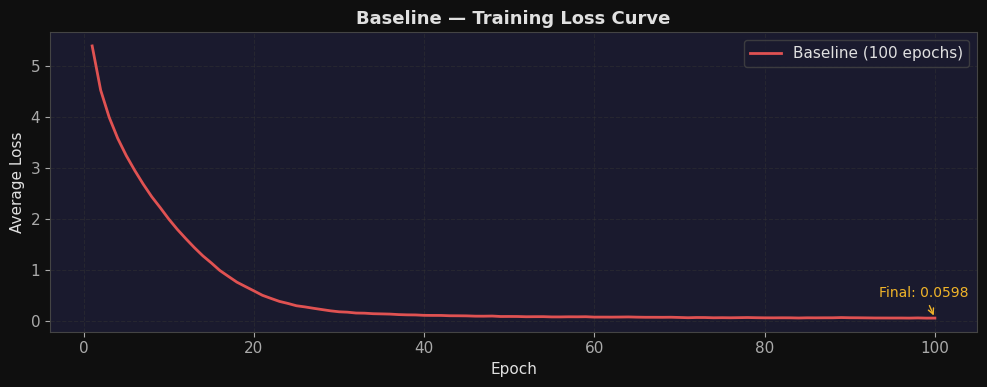

In [11]:
# ── Save baseline model ────────────────────────────────────────────────────────
torch.save(baseline_model.state_dict(), "transformer_translation_final.pth")
print("✅ Baseline model saved → transformer_translation_final.pth")

# ── Loss curve (baseline only) ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, BASELINE_EPOCHS+1), baseline_loss_history,
        color=BASELINE_COLOR, linewidth=2, label="Baseline (100 epochs)")
ax.set_title("Baseline — Training Loss Curve", fontsize=13, fontweight="bold")
ax.set_xlabel("Epoch");  ax.set_ylabel("Average Loss")
ax.legend();  ax.grid(True)
ax.annotate(f"Final: {baseline_loss_history[-1]:.4f}",
            xy=(BASELINE_EPOCHS, baseline_loss_history[-1]),
            xytext=(-40, 15), textcoords="offset points",
            arrowprops=dict(arrowstyle="->", color=ACCENT_COLOR),
            color=ACCENT_COLOR, fontsize=10)
plt.tight_layout()
plt.savefig("plot_baseline_loss.png", dpi=130, bbox_inches="tight")
plt.show()

---
## 🟡 Section 4 — Ray Tune + Optuna Hyperparameter Search

**Search Space (7 hyperparameters):**

| # | Hyperparameter | Method | Range |
|---|---|---|---|
| 1 | `lr` | `loguniform` | 1e-5 → 1e-3 |
| 2 | `batch_size` | `choice` | 32, 64, 128 |
| 3 | `num_heads` | `choice` | 4, 8 |
| 4 | `d_ff` | `choice` | 1024, 2048, 4096 |
| 5 | `dropout` | `uniform` | 0.1 → 0.4 |
| 6 | `num_layers` | `choice` | 4, 6 |
| 7 | `warmup_epochs` | `choice` | 2, 5, 10 |

**ASHA Scheduler** prunes underperforming trials after 5 epochs — drastically reducing compute.

In [12]:
def train_tune(config):
    import torch, torch.nn as nn, torch.optim as optim, ray
    from torch.utils.data import DataLoader

    shared      = ray.get(config["data_ref"])
    df_l        = shared["df"];  ev = shared["en_vocab"];  hv = shared["hi_vocab"]

    lr          = config["lr"];         bs     = config["batch_size"]
    nheads      = config["num_heads"];  d_ff   = config["d_ff"]
    dropout     = config["dropout"];    nlayers= config["num_layers"]
    warmup      = config["warmup_epochs"]
    n_epochs    = config.get("num_epochs", 30)

    dev    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    sp_idx = ev["<pad>"];   tp_idx = hv["<pad>"]

    loader = DataLoader(
        TranslationDataset(df_l, ev, hv, max_len=MAX_LEN),
        batch_size=bs, shuffle=True, collate_fn=collate_fn, num_workers=0
    )

    model = Transformer(len(ev), len(hv), D_MODEL, nlayers, nheads, d_ff, MAX_LEN, dropout).to(dev)
    crit  = nn.CrossEntropyLoss(ignore_index=tp_idx)
    opt   = optim.Adam(model.parameters(), lr=lr, betas=(0.9,0.98), eps=1e-9)
    sched = torch.optim.lr_scheduler.LambdaLR(
        opt, lambda e: float(e+1)/max(1,warmup) if e<warmup else 1.0
    )

    for epoch in range(n_epochs):
        model.train();  ep_loss = 0.0
        for src,ti,to in loader:
            src,ti,to = src.to(dev),ti.to(dev),to.to(dev)
            out  = model(src,ti,sp_idx,tp_idx)
            loss = crit(out.view(-1,out.shape[-1]),to.reshape(-1))
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step();  ep_loss += loss.item()
        sched.step()
        tune.report({"loss": ep_loss/len(loader), "epoch": epoch+1})

print("✅ train_tune() defined")

✅ train_tune() defined


In [13]:
import os
os.environ["RAY_AIR_NEW_OUTPUT"] = "0"

ray.init(ignore_reinit_error=True)

data_ref = ray.put({"df": df, "en_vocab": en_vocab, "hi_vocab": hi_vocab})

param_space = {
    "data_ref"     : data_ref,
    "num_epochs"   : 30,
    "lr"           : tune.loguniform(1e-5, 1e-3),
    "batch_size"   : tune.choice([32, 64, 128]),
    "num_heads"    : tune.choice([4, 8]),
    "d_ff"         : tune.choice([1024, 2048, 4096]),
    "dropout"      : tune.uniform(0.1, 0.4),
    "num_layers"   : tune.choice([4, 6]),
    "warmup_epochs": tune.choice([2, 5, 10]),
}

optuna_search  = OptunaSearch(metric="loss", mode="min")
asha_scheduler = ASHAScheduler(metric="loss", mode="min",
                               max_t=30, grace_period=5, reduction_factor=2)

print("🚀 Starting Ray Tune sweep — 10 trials × ≤30 epochs (ASHA prunes early)...")
sweep_start = time.time()

results = tune.run(
    train_tune,
    name="M25CSA037_sweep",
    config=param_space,
    num_samples=10,
    search_alg=optuna_search,
    scheduler=asha_scheduler,
    resources_per_trial={"cpu": 1, "gpu": 0.5},
    max_concurrent_trials=1,
    verbose=1,
)

sweep_time = time.time() - sweep_start
print(f"\n✅ Sweep done in {sweep_time/60:.1f} min")

2026-03-18 19:23:57,066	INFO worker.py:2013 -- Started a local Ray instance.
[I 2026-03-18 19:24:00,178] A new study created in memory with name: optuna


🚀 Starting Ray Tune sweep — 10 trials × ≤30 epochs (ASHA prunes early)...
== Status ==
Current time: 2026-03-18 19:24:02 (running for 00:00:00.17)
Using AsyncHyperBand: num_stopped=0
Bracket: Iter 20.000: None | Iter 10.000: None | Iter 5.000: None
Logical resource usage: 0/2 CPUs, 0/1 GPUs (0.0/1.0 accelerator_type:T4)
Result logdir: /tmp/ray/session_2026-03-18_19-23-46_166513_3643/artifacts/2026-03-18_19-24-00/M25CSA013_sweep/driver_artifacts
Number of trials: 1/10 (1 PENDING)


== Status ==
Current time: 2026-03-18 19:24:07 (running for 00:00:05.23)
Using AsyncHyperBand: num_stopped=0
Bracket: Iter 20.000: None | Iter 10.000: None | Iter 5.000: None
Logical resource usage: 1.0/2 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:T4)
Result logdir: /tmp/ray/session_2026-03-18_19-23-46_166513_3643/artifacts/2026-03-18_19-24-00/M25CSA013_sweep/driver_artifacts
Number of trials: 1/10 (1 PENDING)


== Status ==
Current time: 2026-03-18 19:24:12 (running for 00:00:10.27)
Using AsyncHyperBand: num

(train_tune pid=24396) [2026-03-18 20:02:24,907 E 24396 24460] logging.cc:118: Unhandled exception: St12out_of_range. what(): absl::container_internal::raw_hash_map<>::at /usr/local/lib/python3.12/dist-packages/ray/_raylet.so(+0x170be2a) [0x7f5f003cce2a] ray::operator<<()
(train_tune pid=24396) /usr/local/lib/python3.12/dist-packages/ray/_raylet.so(+0x170c8dc) [0x7f5f003cd8dc] ray::RayLog::operator<< <>()
(train_tune pid=24396) /usr/local/lib/python3.12/dist-packages/ray/_raylet.so(+0x883cc1) [0x7f5eff544cc1] ray::TerminateHandler()
(train_tune pid=24396) /lib/x86_64-linux-gnu/libstdc++.so.6(+0xae20c) [0x7f5efeb3e20c]
(train_tune pid=24396) /lib/x86_64-linux-gnu/libstdc++.so.6(+0xae277) [0x7f5efeb3e277]
(train_tune pid=24396) /lib/x86_64-linux-gnu/libstdc++.so.6(+0xae4d8) [0x7f5efeb3e4d8]
(train_tune pid=24396) /usr/local/lib/python3.12/dist-packages/ray/_raylet.so(+0x8857c1) [0x7f5eff5467c1] absl::lts_20230802::base_internal::ThrowStdOutOfRange()
(train_tune pid=24396) /usr/local/lib/

== Status ==
Current time: 2026-03-18 20:02:25 (running for 00:38:22.99)
Using AsyncHyperBand: num_stopped=7
Bracket: Iter 20.000: -0.9337932006005318 | Iter 10.000: -2.658436183967898 | Iter 5.000: -3.941365126640566
Logical resource usage: 0/2 CPUs, 0/1 GPUs (0.0/1.0 accelerator_type:T4)
Result logdir: /tmp/ray/session_2026-03-18_19-23-46_166513_3643/artifacts/2026-03-18_19-24-00/M25CSA013_sweep/driver_artifacts
Number of trials: 8/10 (1 PENDING, 7 TERMINATED)


== Status ==
Current time: 2026-03-18 20:02:30 (running for 00:38:28.03)
Using AsyncHyperBand: num_stopped=7
Bracket: Iter 20.000: -0.9337932006005318 | Iter 10.000: -2.658436183967898 | Iter 5.000: -3.941365126640566
Logical resource usage: 1.0/2 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:T4)
Result logdir: /tmp/ray/session_2026-03-18_19-23-46_166513_3643/artifacts/2026-03-18_19-24-00/M25CSA013_sweep/driver_artifacts
Number of trials: 8/10 (1 PENDING, 7 TERMINATED)


== Status ==
Current time: 2026-03-18 20:02:35 (running fo

2026-03-18 20:07:14,134	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/root/ray_results/M25CSA013_sweep' in 0.0187s.
2026-03-18 20:07:14,142	INFO tune.py:1041 -- Total run time: 2594.00 seconds (2591.74 seconds for the tuning loop).


== Status ==
Current time: 2026-03-18 20:07:14 (running for 00:43:11.76)
Using AsyncHyperBand: num_stopped=10
Bracket: Iter 20.000: -0.9337932006005318 | Iter 10.000: -2.7408362876984382 | Iter 5.000: -3.9624353801050494
Logical resource usage: 1.0/2 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:T4)
Result logdir: /tmp/ray/session_2026-03-18_19-23-46_166513_3643/artifacts/2026-03-18_19-24-00/M25CSA013_sweep/driver_artifacts
Number of trials: 10/10 (10 TERMINATED)



✅ Sweep done in 43.2 min


In [14]:
results_df  = results.dataframe()
best_config = results.get_best_config(metric="loss", mode="min")
best_trial  = results.get_best_trial(metric="loss", mode="min")

print(f"Trials completed : {len(results_df)}")
print(f"Best loss        : {best_trial.last_result['loss']:.4f}")
print(f"Best epoch       : {best_trial.last_result.get('epoch','N/A')}")
print()
print("Best hyperparameters found:")
for k in ["lr","batch_size","num_heads","d_ff","dropout","num_layers","warmup_epochs"]:
    v = best_config.get(k,"—")
    print(f"  {k:<18} : {v:.4f}" if isinstance(v,float) else f"  {k:<18} : {v}")

Trials completed : 10
Best loss        : 0.2968
Best epoch       : 30

Best hyperparameters found:
  lr                 : 0.0002
  batch_size         : 128
  num_heads          : 4
  d_ff               : 1024
  dropout            : 0.1656
  num_layers         : 6
  warmup_epochs      : 2


---
## 📊 Section 5 — Sweep Analysis Plots

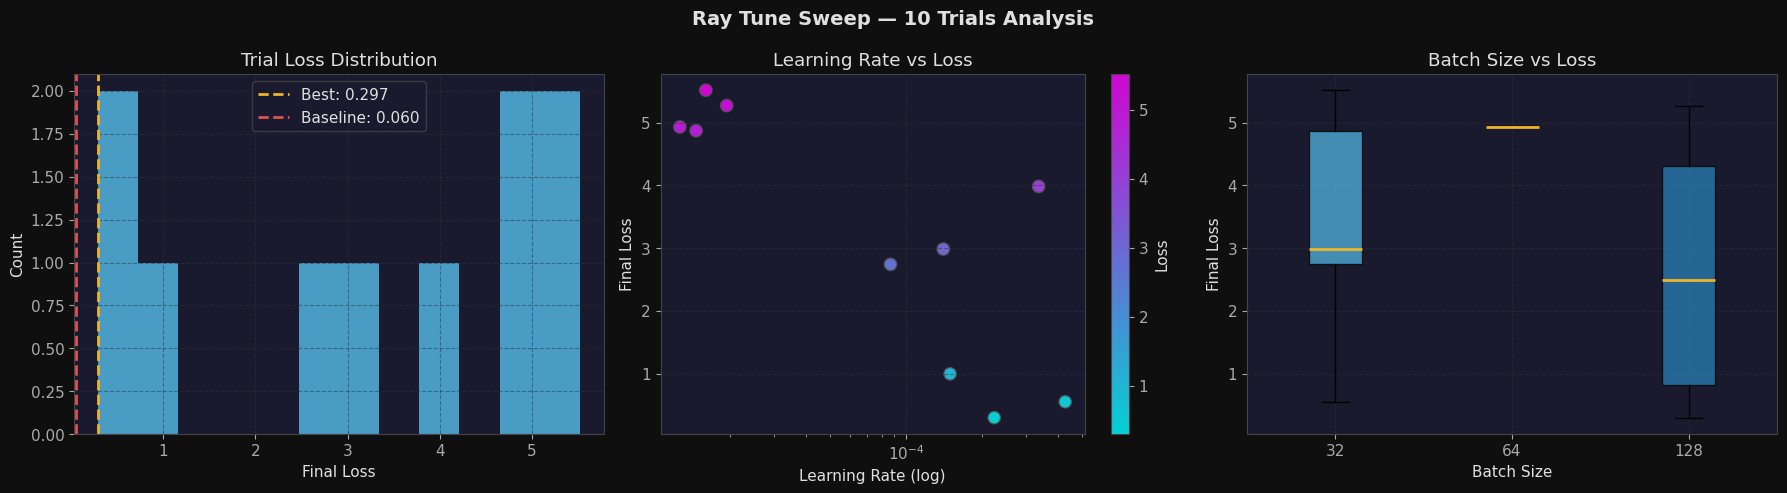

✅ Sweep analysis plot saved


In [15]:
# ── Plot 1: Trial loss distribution + LR vs loss + parallel coords ──────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Ray Tune Sweep — 10 Trials Analysis", fontsize=14, fontweight="bold")

# — 1a: Trial loss histogram ──────────────────────────────────────────────────
ax = axes[0]
ax.hist(results_df["loss"].dropna(), bins=12, color=TUNED_COLOR, edgecolor="none", alpha=0.85)
ax.axvline(best_trial.last_result["loss"], color=ACCENT_COLOR, linestyle="--", linewidth=2,
           label=f"Best: {best_trial.last_result['loss']:.3f}")
ax.axvline(baseline_loss_history[-1], color=BASELINE_COLOR, linestyle="--", linewidth=2,
           label=f"Baseline: {baseline_loss_history[-1]:.3f}")
ax.set_title("Trial Loss Distribution")
ax.set_xlabel("Final Loss");  ax.set_ylabel("Count")
ax.legend();  ax.grid(True)

# — 1b: LR vs loss scatter ────────────────────────────────────────────────────
ax = axes[1]
lr_col = "config/lr" if "config/lr" in results_df.columns else None
if lr_col:
    sc = ax.scatter(results_df[lr_col], results_df["loss"],
                    c=results_df["loss"], cmap="cool", alpha=0.8, s=80, edgecolors="#555")
    plt.colorbar(sc, ax=ax, label="Loss")
ax.set_xscale("log")
ax.set_title("Learning Rate vs Loss")
ax.set_xlabel("Learning Rate (log)");  ax.set_ylabel("Final Loss")
ax.grid(True)

# — 1c: Batch size vs loss boxplot ────────────────────────────────────────────
ax = axes[2]
bs_col = "config/batch_size" if "config/batch_size" in results_df.columns else None
if bs_col:
    groups = {bs: grp["loss"].dropna().tolist()
              for bs, grp in results_df.groupby(bs_col)}
    labels  = sorted(groups.keys())
    data    = [groups[k] for k in labels]
    bp = ax.boxplot(data, labels=labels, patch_artist=True,
                    medianprops=dict(color=ACCENT_COLOR, linewidth=2))
    colors = [TUNED_COLOR, "#7ec8e3", "#2980b9"]
    for patch, c in zip(bp["boxes"], colors[:len(bp["boxes"])]):
        patch.set_facecolor(c);  patch.set_alpha(0.75)
ax.set_title("Batch Size vs Loss")
ax.set_xlabel("Batch Size");  ax.set_ylabel("Final Loss")
ax.grid(True)

plt.tight_layout()
plt.savefig("plot_sweep_analysis.png", dpi=130, bbox_inches="tight")
plt.show()
print("✅ Sweep analysis plot saved")

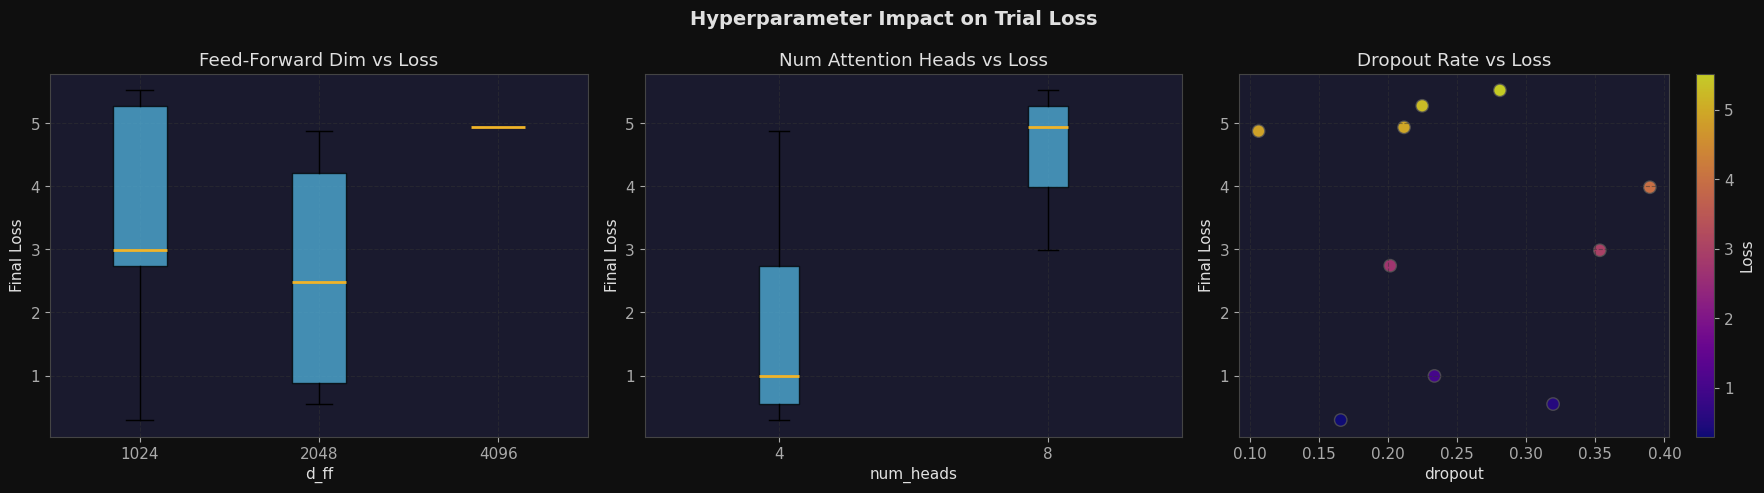

✅ Hyperparameter impact plot saved


In [16]:
# ── Plot 2: d_ff, num_heads, dropout vs loss ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Hyperparameter Impact on Trial Loss", fontsize=14, fontweight="bold")

hp_cols = {
    "config/d_ff"        : ("d_ff",        "Feed-Forward Dim vs Loss"),
    "config/num_heads"   : ("num_heads",    "Num Attention Heads vs Loss"),
    "config/dropout"     : ("dropout",      "Dropout Rate vs Loss"),
}

for ax, (col, (param, title)) in zip(axes, hp_cols.items()):
    available = col in results_df.columns
    if available:
        is_cat = results_df[col].nunique() <= 5
        if is_cat:
            groups = {v: g["loss"].dropna().tolist() for v, g in results_df.groupby(col)}
            labels = sorted(groups.keys())
            bp = ax.boxplot([groups[k] for k in labels], labels=labels, patch_artist=True,
                            medianprops=dict(color=ACCENT_COLOR, linewidth=2))
            for patch in bp["boxes"]:
                patch.set_facecolor(TUNED_COLOR); patch.set_alpha(0.75)
        else:
            sc = ax.scatter(results_df[col], results_df["loss"],
                            c=results_df["loss"], cmap="plasma", alpha=0.8, s=80, edgecolors="#555")
            plt.colorbar(sc, ax=ax, label="Loss")
    ax.set_title(title)
    ax.set_xlabel(param);  ax.set_ylabel("Final Loss")
    ax.grid(True)

plt.tight_layout()
plt.savefig("plot_hyperparameter_impact.png", dpi=130, bbox_inches="tight")
plt.show()
print("✅ Hyperparameter impact plot saved")

---
## 🟢 Section 6 — Train Best Model (≤ 30 Epochs, Optimised Hyperparameters)

In [17]:
BEST_LR      = best_config["lr"]
BEST_BS      = best_config["batch_size"]
BEST_HEADS   = best_config["num_heads"]
BEST_DFF     = best_config["d_ff"]
BEST_DROP    = best_config["dropout"]
BEST_LAYERS  = best_config["num_layers"]
BEST_WARMUP  = best_config["warmup_epochs"]
TUNED_EPOCHS = 30

print(f"Training best model for {TUNED_EPOCHS} epochs:")
print(f"  lr={BEST_LR:.2e}  batch={BEST_BS}  heads={BEST_HEADS}")
print(f"  d_ff={BEST_DFF}  dropout={BEST_DROP:.3f}  layers={BEST_LAYERS}  warmup={BEST_WARMUP}")

tuned_loader = DataLoader(
    TranslationDataset(df, en_vocab, hi_vocab, MAX_LEN),
    batch_size=BEST_BS, shuffle=True, collate_fn=collate_fn
)

tuned_model = Transformer(
    src_vsz=len(en_vocab), tgt_vsz=len(hi_vocab),
    d_model=D_MODEL, nlayers=BEST_LAYERS, nheads=BEST_HEADS,
    d_ff=BEST_DFF, max_len=MAX_LEN, dropout=BEST_DROP
).to(DEVICE)

tuned_crit  = nn.CrossEntropyLoss(ignore_index=TGT_PAD_IDX)
tuned_opt   = optim.Adam(tuned_model.parameters(), lr=BEST_LR, betas=(0.9,0.98), eps=1e-9)
tuned_sched = torch.optim.lr_scheduler.LambdaLR(
    tuned_opt, lambda e: float(e+1)/max(1,BEST_WARMUP) if e<BEST_WARMUP else 1.0
)
print(f"\nModel params: {sum(p.numel() for p in tuned_model.parameters()):,}")

Training best model for 30 epochs:
  lr=2.24e-04  batch=128  heads=4
  d_ff=1024  dropout=0.166  layers=6  warmup=2

Model params: 34,246,390


In [18]:
tuned_loss_history = []
tuned_start        = time.time()

for epoch in range(TUNED_EPOCHS):
    tuned_model.train();  ep_loss = 0.0
    loop = tqdm(tuned_loader, desc=f"Tuned Epoch [{epoch+1}/{TUNED_EPOCHS}]", leave=False)
    for src,ti,to in loop:
        src,ti,to = src.to(DEVICE),ti.to(DEVICE),to.to(DEVICE)
        out  = tuned_model(src,ti,SRC_PAD_IDX,TGT_PAD_IDX)
        loss = tuned_crit(out.view(-1,out.shape[-1]),to.view(-1))
        tuned_opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(tuned_model.parameters(), 1.0)
        tuned_opt.step();  ep_loss += loss.item()
        loop.set_postfix(loss=f"{loss.item():.4f}")
    tuned_sched.step()
    avg = ep_loss / len(tuned_loader)
    tuned_loss_history.append(avg)
    print(f"  Epoch {epoch+1:3d}/{TUNED_EPOCHS}  |  avg_loss = {avg:.4f}")

tuned_time = time.time() - tuned_start
tuned_bleu = evaluate_bleu(tuned_model)

print(f"\n{'='*55}")
print(f"  TUNED MODEL TRAINING COMPLETE")
print(f"{'='*55}")
print(f"  Total time  : {tuned_time/60:.1f} min  ({tuned_time:.0f} s)")
print(f"  Final loss  : {tuned_loss_history[-1]:.4f}")
print(f"  BLEU Score  : {tuned_bleu*100:.2f}%")
print(f"{'='*55}")

  Epoch   1/30  |  avg_loss = 5.6781


  Epoch   2/30  |  avg_loss = 4.8263


  Epoch   3/30  |  avg_loss = 4.2719


  Epoch   4/30  |  avg_loss = 3.8553


  Epoch   5/30  |  avg_loss = 3.5122


...

  Epoch  26/30  |  avg_loss = 0.4422


  Epoch  27/30  |  avg_loss = 0.4016


  Epoch  28/30  |  avg_loss = 0.3567


  Epoch  29/30  |  avg_loss = 0.3216


  Epoch  30/30  |  avg_loss = 0.3000

  TUNED MODEL TRAINING COMPLETE
  Total time  : 8.2 min  (491 s)
  Final loss  : 0.3000
  BLEU Score  : 62.30%


---
## 📈 Section 7 — Baseline vs Tuned Model — Comparison Plots

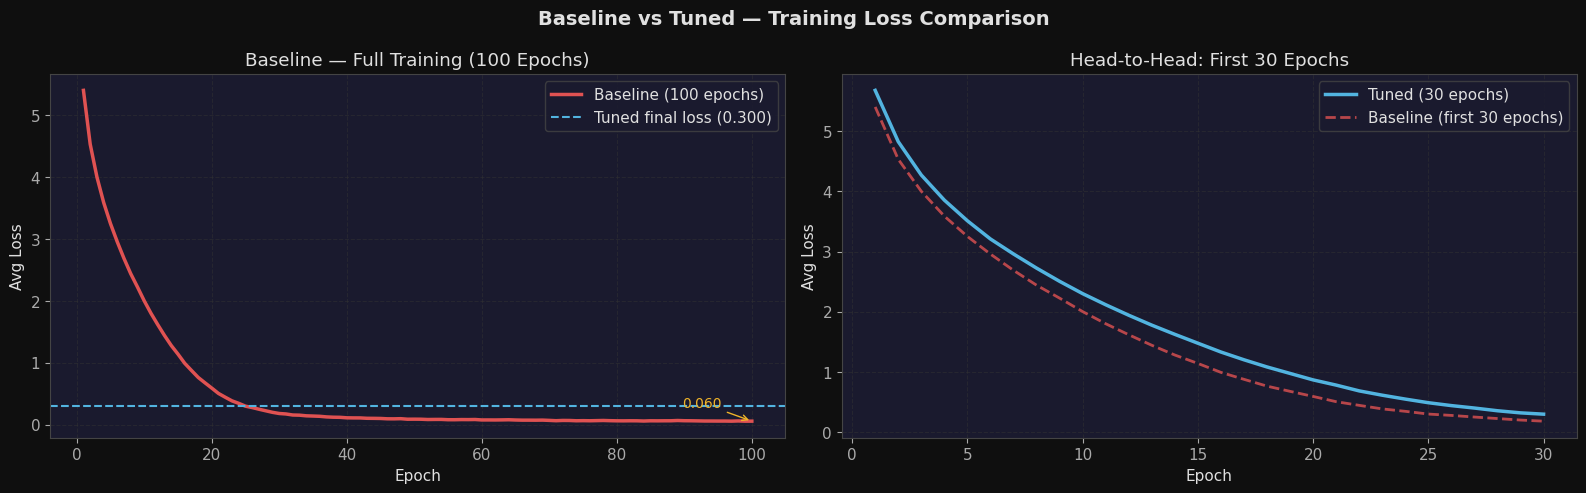

✅ Loss comparison plot saved


In [19]:
# ── Plot A: Loss curves side by side (same time axis via epochs) ──────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Baseline vs Tuned — Training Loss Comparison", fontsize=14, fontweight="bold")

# Full 100-epoch baseline
ax = axes[0]
ax.plot(range(1,BASELINE_EPOCHS+1), baseline_loss_history,
        color=BASELINE_COLOR, linewidth=2.5, label="Baseline (100 epochs)")
ax.axhline(tuned_loss_history[-1], color=TUNED_COLOR, linestyle="--", linewidth=1.5,
           label=f"Tuned final loss ({tuned_loss_history[-1]:.3f})")
ax.set_title("Baseline — Full Training (100 Epochs)")
ax.set_xlabel("Epoch");  ax.set_ylabel("Avg Loss")
ax.legend();  ax.grid(True)
ax.annotate(f"{baseline_loss_history[-1]:.3f}",
            xy=(BASELINE_EPOCHS, baseline_loss_history[-1]),
            xytext=(-50,10), textcoords="offset points",
            arrowprops=dict(arrowstyle="->",color=ACCENT_COLOR),
            color=ACCENT_COLOR, fontsize=10)

# Tuned 30-epoch + first 30 epochs of baseline overlay
ax = axes[1]
ax.plot(range(1,TUNED_EPOCHS+1), tuned_loss_history,
        color=TUNED_COLOR, linewidth=2.5, label=f"Tuned ({TUNED_EPOCHS} epochs)")
ax.plot(range(1,TUNED_EPOCHS+1), baseline_loss_history[:TUNED_EPOCHS],
        color=BASELINE_COLOR, linewidth=2, linestyle="--", alpha=0.8,
        label=f"Baseline (first {TUNED_EPOCHS} epochs)")
ax.set_title(f"Head-to-Head: First {TUNED_EPOCHS} Epochs")
ax.set_xlabel("Epoch");  ax.set_ylabel("Avg Loss")
ax.legend();  ax.grid(True)

plt.tight_layout()
plt.savefig("plot_loss_comparison.png", dpi=130, bbox_inches="tight")
plt.show()
print("✅ Loss comparison plot saved")

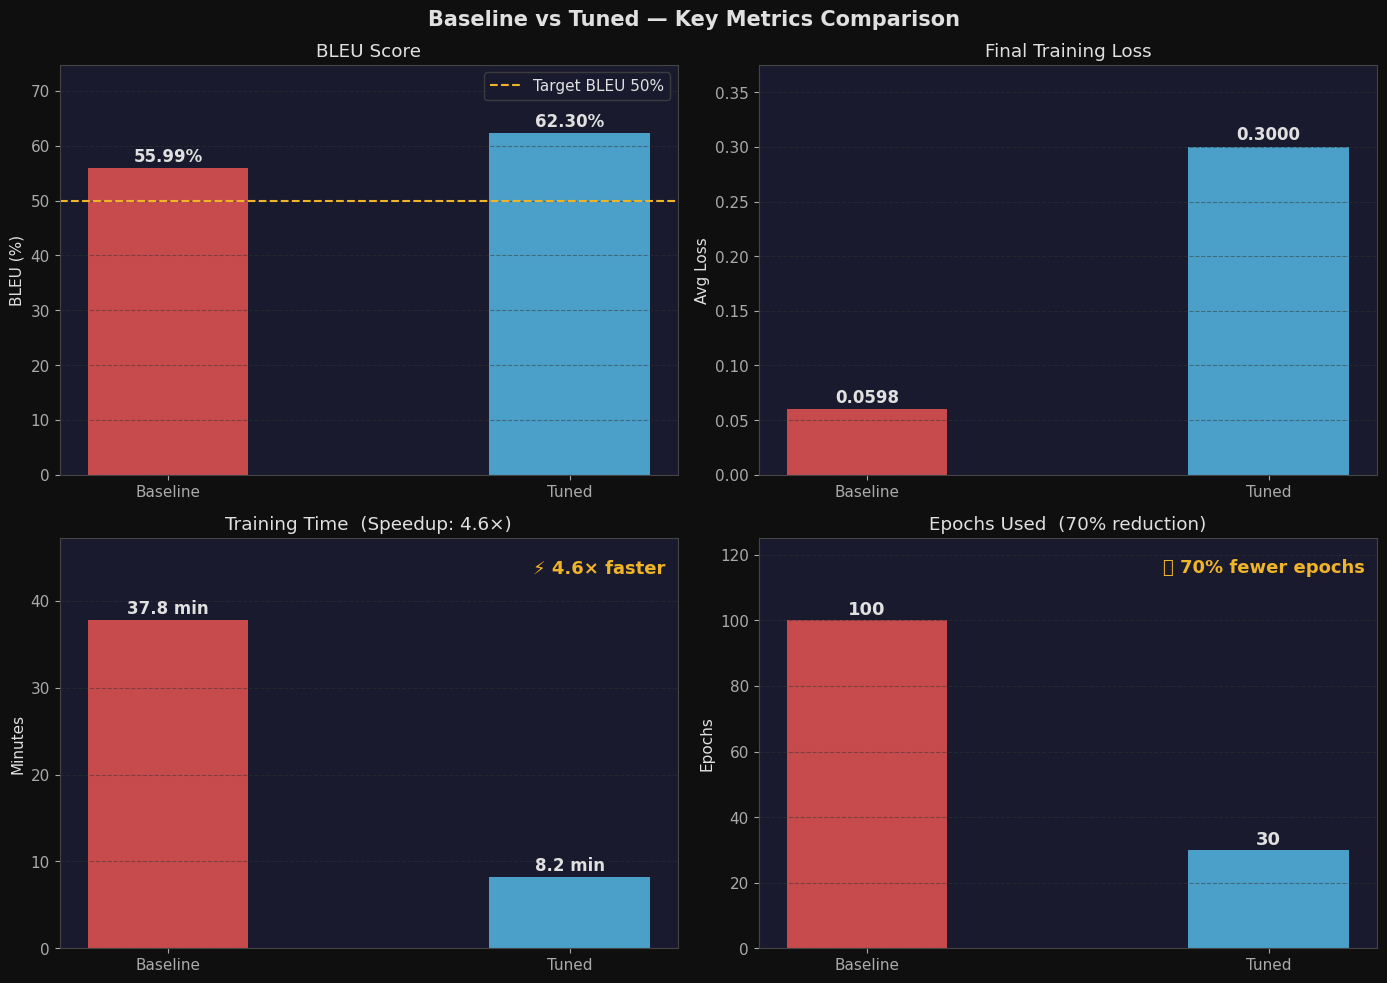

✅ Metrics comparison plot saved


In [20]:
# ── Plot B: BLEU + Loss + Time + Epochs ── 4-panel bar chart ─────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Baseline vs Tuned — Key Metrics Comparison", fontsize=15, fontweight="bold")

models    = ["Baseline", "Tuned"]
bar_kw    = dict(width=0.4, edgecolor="none", alpha=0.88)
colors    = [BASELINE_COLOR, TUNED_COLOR]

# — B1: BLEU Score ────────────────────────────────────────────────────────────
ax = axes[0,0]
vals = [baseline_bleu*100, tuned_bleu*100]
bars = ax.bar(models, vals, color=colors, **bar_kw)
ax.axhline(50, color=ACCENT_COLOR, linestyle="--", linewidth=1.5, label="Target BLEU 50%")
for bar, val in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.5, f"{val:.2f}%",
            ha="center", va="bottom", fontweight="bold", fontsize=12)
ax.set_title("BLEU Score");  ax.set_ylabel("BLEU (%)");  ax.legend();  ax.grid(True, axis="y")
ax.set_ylim(0, max(vals)*1.2)

# — B2: Final Loss ────────────────────────────────────────────────────────────
ax = axes[0,1]
vals = [baseline_loss_history[-1], tuned_loss_history[-1]]
bars = ax.bar(models, vals, color=colors, **bar_kw)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.003, f"{val:.4f}",
            ha="center", va="bottom", fontweight="bold", fontsize=12)
ax.set_title("Final Training Loss");  ax.set_ylabel("Avg Loss");  ax.grid(True, axis="y")
ax.set_ylim(0, max(vals)*1.25)

# — B3: Training Time ─────────────────────────────────────────────────────────
ax = axes[1,0]
vals = [baseline_time/60, tuned_time/60]
bars = ax.bar(models, vals, color=colors, **bar_kw)
speedup = baseline_time / tuned_time
for bar, val in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.3, f"{val:.1f} min",
            ha="center", va="bottom", fontweight="bold", fontsize=12)
ax.set_title(f"Training Time  (Speedup: {speedup:.1f}×)")
ax.set_ylabel("Minutes");  ax.grid(True, axis="y")
ax.set_ylim(0, max(vals)*1.25)
ax.text(0.98, 0.95, f"⚡ {speedup:.1f}× faster",
        transform=ax.transAxes, ha="right", va="top",
        fontsize=13, color=ACCENT_COLOR, fontweight="bold")

# — B4: Epochs used ───────────────────────────────────────────────────────────
ax = axes[1,1]
vals = [BASELINE_EPOCHS, TUNED_EPOCHS]
bars = ax.bar(models, vals, color=colors, **bar_kw)
reduction = (1 - TUNED_EPOCHS/BASELINE_EPOCHS)*100
for bar, val in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.5, str(val),
            ha="center", va="bottom", fontweight="bold", fontsize=13)
ax.set_title(f"Epochs Used  ({reduction:.0f}% reduction)")
ax.set_ylabel("Epochs");  ax.grid(True, axis="y")
ax.set_ylim(0, BASELINE_EPOCHS*1.25)
ax.text(0.98, 0.95, f"📉 {reduction:.0f}% fewer epochs",
        transform=ax.transAxes, ha="right", va="top",
        fontsize=13, color=ACCENT_COLOR, fontweight="bold")

plt.tight_layout()
plt.savefig("plot_metrics_comparison.png", dpi=130, bbox_inches="tight")
plt.show()
print("✅ Metrics comparison plot saved")

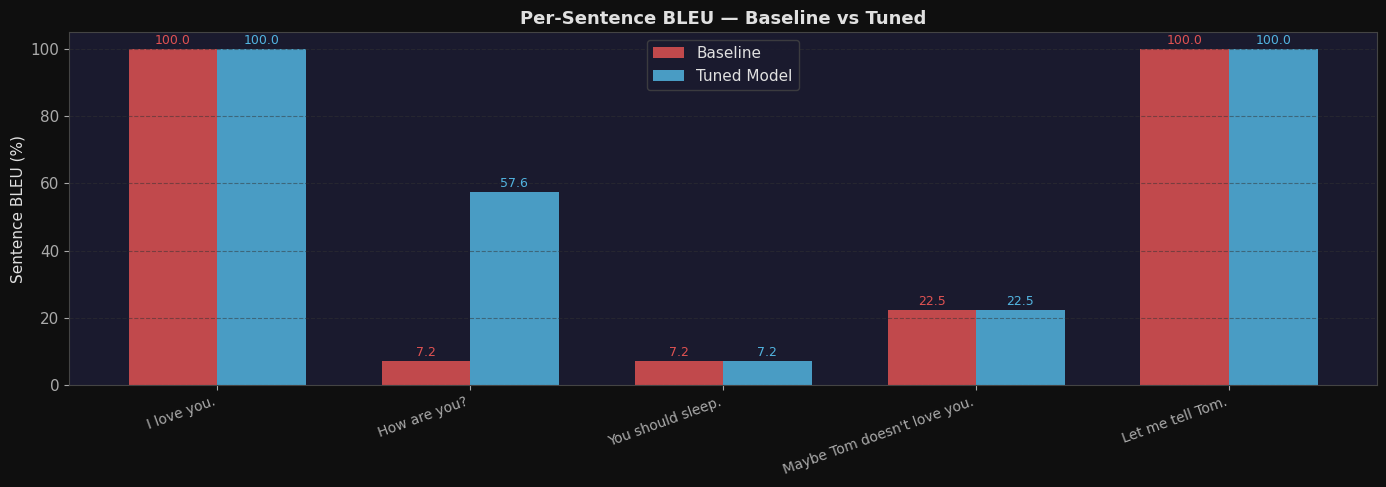

✅ Per-sentence BLEU plot saved


In [21]:
# ── Plot C: Per-sentence BLEU comparison ─────────────────────────────────────
from nltk.translate.bleu_score import sentence_bleu

sentence_labels, base_scores, tuned_scores = [], [], []

for en_s, hi_s in val_dataset:
    b_pred  = translate_sentence(baseline_model, en_s)
    t_pred  = translate_sentence(tuned_model,    en_s)
    ref     = [hi_s.split()]
    b_score = sentence_bleu(ref, b_pred.split(),  smoothing_function=smoothie)
    t_score = sentence_bleu(ref, t_pred.split(),  smoothing_function=smoothie)
    sentence_labels.append(en_s[:28] + "…" if len(en_s)>28 else en_s)
    base_scores.append(b_score*100)
    tuned_scores.append(t_score*100)

x     = np.arange(len(sentence_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width/2, base_scores,  width, label="Baseline",    color=BASELINE_COLOR, alpha=0.85)
ax.bar(x + width/2, tuned_scores, width, label="Tuned Model", color=TUNED_COLOR,    alpha=0.85)

ax.set_xticks(x);  ax.set_xticklabels(sentence_labels, rotation=20, ha="right", fontsize=10)
ax.set_ylabel("Sentence BLEU (%)")
ax.set_title("Per-Sentence BLEU — Baseline vs Tuned", fontsize=13, fontweight="bold")
ax.legend();  ax.grid(True, axis="y")

for i, (bv, tv) in enumerate(zip(base_scores, tuned_scores)):
    ax.text(i-width/2, bv+0.5, f"{bv:.1f}", ha="center", va="bottom", fontsize=9, color=BASELINE_COLOR)
    ax.text(i+width/2, tv+0.5, f"{tv:.1f}", ha="center", va="bottom", fontsize=9, color=TUNED_COLOR)

plt.tight_layout()
plt.savefig("plot_per_sentence_bleu.png", dpi=130, bbox_inches="tight")
plt.show()
print("✅ Per-sentence BLEU plot saved")

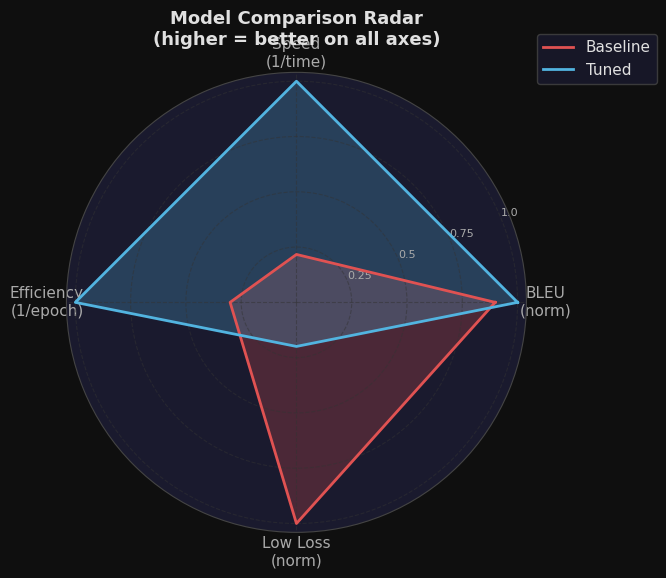

✅ Radar chart saved


In [22]:
# ── Plot D: Radar chart — multi-dimensional comparison ───────────────────────
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

categories  = ["BLEU\n(norm)", "Speed\n(1/time)", "Efficiency\n(1/epoch)", "Low Loss\n(norm)"]
N           = len(categories)

# Normalise each metric so that higher = better
bleu_norm_b = baseline_bleu / max(baseline_bleu, tuned_bleu)
bleu_norm_t = tuned_bleu    / max(baseline_bleu, tuned_bleu)
spd_b       = tuned_time   / baseline_time          # baseline speed relative to tuned
spd_t       = 1.0                                    # tuned is the reference
eff_b       = TUNED_EPOCHS / BASELINE_EPOCHS         # baseline epoch efficiency
eff_t       = 1.0
loss_b      = tuned_loss_history[-1] / max(baseline_loss_history[-1], tuned_loss_history[-1])
loss_t      = 1.0 if tuned_loss_history[-1] <= baseline_loss_history[-1] else               baseline_loss_history[-1] / tuned_loss_history[-1]

baseline_vals = [bleu_norm_b, spd_b,  eff_b,  loss_b]
tuned_vals    = [bleu_norm_t, spd_t,  eff_t,  loss_t]

angles = [n / float(N) * 2 * math.pi for n in range(N)]
angles += angles[:1]
baseline_vals += baseline_vals[:1]
tuned_vals    += tuned_vals[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
fig.patch.set_facecolor("#0f0f0f")
ax.set_facecolor("#1a1a2e")

ax.plot(angles, baseline_vals, color=BASELINE_COLOR, linewidth=2, label="Baseline")
ax.fill(angles, baseline_vals, color=BASELINE_COLOR, alpha=0.25)
ax.plot(angles, tuned_vals,    color=TUNED_COLOR,    linewidth=2, label="Tuned")
ax.fill(angles, tuned_vals,    color=TUNED_COLOR,    alpha=0.25)

ax.set_xticks(angles[:-1]);  ax.set_xticklabels(categories, fontsize=11)
ax.set_yticks([0.25,0.5,0.75,1.0]);  ax.set_yticklabels(["0.25","0.5","0.75","1.0"], fontsize=8)
ax.set_title("Model Comparison Radar\n(higher = better on all axes)",
             size=13, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
ax.grid(color="#333")

plt.tight_layout()
plt.savefig("plot_radar_comparison.png", dpi=130, bbox_inches="tight")
plt.show()
print("✅ Radar chart saved")

---
## 🗣️ Section 8 — Sample Translations: Baseline vs Tuned

In [23]:
print(f"{'='*72}")
print(f"{'English':<30}  {'Baseline (100ep)':^18}  {'Tuned (30ep)':^18}")
print(f"{'='*72}")

for en_s, hi_ref in val_dataset:
    b_pred = translate_sentence(baseline_model, en_s)
    t_pred = translate_sentence(tuned_model,    en_s)
    print(f"\n  🗣  EN  : {en_s}")
    print(f"  📖  REF : {hi_ref}")
    print(f"  🔵  BASE: {b_pred}")
    print(f"  🟢  TUNE: {t_pred}")

print(f"\n{'='*72}")

English                          Baseline (100ep)      Tuned (30ep)   

  🗣  EN  : I love you.
  📖  REF : मैं तुमसे प्यार करता हूँ।
  🔵  BASE: मैं तुमसे प्यार करता हूँ।
  🟢  TUNE: मैं तुमसे प्यार करता हूँ।

  🗣  EN  : How are you?
  📖  REF : आप कैसे हैं?
  🔵  BASE: कैसे हो, <unk>
  🟢  TUNE: आप कैसे हैं?

  🗣  EN  : You should sleep.
  📖  REF : आपको सोना चाहिए।
  🔵  BASE: तुम्हें सो चाहिए।
  🟢  TUNE: तुम्हें जल्दी चाहिए।

  🗣  EN  : Maybe Tom doesn't love you.
  📖  REF : टॉम शायद तुमसे प्यार नहीं करता है।
  🔵  BASE: टॉम को तुमसे प्यार नहीं है।
  🟢  TUNE: टॉम को तुमसे प्यार नहीं है।

  🗣  EN  : Let me tell Tom.
  📖  REF : मुझे टॉम को बताने दीजिए।
  🔵  BASE: मुझे टॉम को बताने दीजिए।
  🟢  TUNE: मुझे टॉम को बताने दीजिए।



---
## 🏆 Section 9 — Final Results Summary

In [24]:
print("\n" + "="*65)
print("  M25CSA037 — ASSIGNMENT 4 — FINAL RESULTS")
print("="*65)
print(f"\n{'Metric':<28} {'Baseline':>15} {'Tuned Model':>15}")
print("-"*60)
print(f"{'BLEU Score':<28} {baseline_bleu*100:>14.2f}% {tuned_bleu*100:>14.2f}%")
print(f"{'Final Training Loss':<28} {baseline_loss_history[-1]:>15.4f} {tuned_loss_history[-1]:>15.4f}")
print(f"{'Epochs Used':<28} {BASELINE_EPOCHS:>15} {TUNED_EPOCHS:>15}")
print(f"{'Training Time (min)':<28} {baseline_time/60:>15.1f} {tuned_time/60:>15.1f}")
print(f"{'LR':<28} {'1e-4':>15} {BEST_LR:>15.2e}")
print(f"{'Batch Size':<28} {BASELINE_BATCH:>15} {BEST_BS:>15}")
print(f"{'Num Heads':<28} {BASELINE_HEADS:>15} {BEST_HEADS:>15}")
print(f"{'d_ff':<28} {BASELINE_DFF:>15} {BEST_DFF:>15}")
print(f"{'Dropout':<28} {BASELINE_DROP:>15.2f} {BEST_DROP:>15.3f}")
print(f"{'Num Layers':<28} {BASELINE_LAYERS:>15} {BEST_LAYERS:>15}")
print("-"*60)
beat_bleu   = "✅ YES" if tuned_bleu   >= baseline_bleu          else "❌ NO"
beat_epochs = "✅ YES" if TUNED_EPOCHS < BASELINE_EPOCHS          else "❌ NO"
speedup_val = baseline_time / tuned_time
print(f"  Beat baseline BLEU      : {beat_bleu}")
print(f"  Fewer epochs than 100   : {beat_epochs}  ({BASELINE_EPOCHS-TUNED_EPOCHS} fewer epochs)")
print(f"  Speed-up factor         : {speedup_val:.1f}×  faster")
print(f"  Epoch reduction         : {(1-TUNED_EPOCHS/BASELINE_EPOCHS)*100:.0f}%")
print("="*65)


  M25CSA037 — ASSIGNMENT 4 — FINAL RESULTS

Metric                              Baseline     Tuned Model
------------------------------------------------------------
BLEU Score                            55.99%          62.30%
Final Training Loss                   0.0598          0.3000
Epochs Used                              100              30
Training Time (min)                     37.8             8.2
LR                                      1e-4        2.24e-04
Batch Size                                60             128
Num Heads                                  8               4
d_ff                                    2048            1024
Dropout                                 0.10           0.166
Num Layers                                 6               6
------------------------------------------------------------
  Beat baseline BLEU      : ✅ YES
  Fewer epochs than 100   : ✅ YES  (70 fewer epochs)
  Speed-up factor         : 4.6×  faster
  Epoch reduction         : 70%


---
## 💾 Section 10 — Save All Files

In [25]:
# ── Save tuned model ─────────────────────────────────────────────────────────
torch.save(tuned_model.state_dict(), "M25CSA037_ass_4_best_model.pth")

# ── Save vocab ────────────────────────────────────────────────────────────────
with open("en_vocab.pkl","wb") as f: pickle.dump(en_vocab, f)
with open("hi_vocab.pkl","wb") as f: pickle.dump(hi_vocab, f)

# ── Save best config ──────────────────────────────────────────────────────────
safe = {k:v for k,v in best_config.items() if isinstance(v,(int,float,str,bool))}
with open("M25CSA037_best_config.json","w") as f: json.dump(safe, f, indent=2)

# ── Summary JSON for report ───────────────────────────────────────────────────
summary = {
    "roll_no": "M25CSA037",
    "baseline": {
        "bleu": round(baseline_bleu*100, 2),
        "final_loss": round(baseline_loss_history[-1], 4),
        "epochs": BASELINE_EPOCHS,
        "time_minutes": round(baseline_time/60, 1)
    },
    "tuned": {
        "bleu": round(tuned_bleu*100, 2),
        "final_loss": round(tuned_loss_history[-1], 4),
        "epochs": TUNED_EPOCHS,
        "time_minutes": round(tuned_time/60, 1)
    },
    "best_hyperparams": safe
}
with open("M25CSA037_summary.json","w") as f: json.dump(summary, f, indent=2)

print("✅ All files saved:")
files = [
    "M25CSA037_ass_4_best_model.pth",
    "transformer_translation_final.pth",
    "M25CSA037_best_config.json",
    "M25CSA037_summary.json",
    "en_vocab.pkl", "hi_vocab.pkl",
    "plot_dataset_eda.png",
    "plot_baseline_loss.png",
    "plot_sweep_analysis.png",
    "plot_hyperparameter_impact.png",
    "plot_loss_comparison.png",
    "plot_metrics_comparison.png",
    "plot_per_sentence_bleu.png",
    "plot_radar_comparison.png",
]
for f in files:
    print(f"  📁 {f}")

✅ All files saved:
  📁 M25CSA037_ass_4_best_model.pth
  📁 transformer_translation_final.pth
  📁 M25CSA037_best_config.json
  📁 M25CSA037_summary.json
  📁 en_vocab.pkl
  📁 hi_vocab.pkl
  📁 plot_dataset_eda.png
  📁 plot_baseline_loss.png
  📁 plot_sweep_analysis.png
  📁 plot_hyperparameter_impact.png
  📁 plot_loss_comparison.png
  📁 plot_metrics_comparison.png
  📁 plot_per_sentence_bleu.png
  📁 plot_radar_comparison.png


In [27]:
import os
!pip install -q huggingface_hub

from huggingface_hub import HfApi
from google.colab import userdata # Import userdata to access secrets

# --- 1. Hugging Face Login --------------------------------------------------
# Retrieve your Hugging Face token from Colab Secrets
# Ensure you have an 'HF_TOKEN' secret set in Colab's Secrets tab
try:
    HF_TOKEN = userdata.get('HF_TOKEN')
    if not HF_TOKEN:
        raise ValueError("HF_TOKEN not found in Colab secrets.")
    print("✅ Hugging Face token successfully loaded from Colab secrets.")
except Exception as e:
    print(f"❌ Error loading Hugging Face token from secrets: {e}")
    print("Please set your Hugging Face token in Colab's Secrets tab (key icon on the left).")
    exit()

api = HfApi(token=HF_TOKEN)

# --- 2. Define files to upload ----------------------------------------------
files_to_upload = [
    "/content/transformer_translation_final.pth",
    "/content/M25CSA037_ass_4_best_model.pth"
]

# --- 3. Get repository name from user ---------------------------------------
repo_name = input("Please enter the name for your Hugging Face repository (e.g., 'my-translation-models'): ")
repo_id = f"{api.whoami()['name']}/{repo_name}"

# --- 4. Create repository if it doesn't exist -------------------------------
try:
    api.create_repo(repo_id=repo_id, exist_ok=True)
    print(f"✅ Repository '{repo_id}' created or already exists.")
except Exception as e:
    print(f"❌ Failed to create or access repository: {e}")
    print("Please ensure your token has write access and the repository name is valid.")
    exit()

# --- 5. Upload files --------------------------------------------------------
print(f"\nUploading files to '{repo_id}'...")
for file_path in files_to_upload:
    if os.path.exists(file_path):
        try:
            api.upload_file(
                path_or_fileobj=file_path,
                path_in_repo=os.path.basename(file_path),
                repo_id=repo_id,
            )
            print(f"  ✅ Successfully uploaded {os.path.basename(file_path)}")
        except Exception as e:
            print(f"  ❌ Failed to upload {os.path.basename(file_path)}: {e}")
    else:
        print(f"  ⚠️ Warning: {file_path} not found. Skipping.")

print(f"\nUpload process complete. You can view your repository at: https://huggingface.co/{repo_id}")

✅ Hugging Face token successfully loaded from Colab secrets.
Please enter the name for your Hugging Face repository (e.g., 'my-translation-models'): ASSIGNMENT_4
✅ Repository 'Gautam20/ASSIGNMENT_4' created or already exists.

Uploading files to 'Gautam20/ASSIGNMENT_4'...


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mer_translation_final.pth:  77%|#######6  |  144MB /  188MB            

  ✅ Successfully uploaded transformer_translation_final.pth


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...A037_ass_4_best_model.pth: 100%|##########|  137MB /  137MB            

  ✅ Successfully uploaded M25CSA037_ass_4_best_model.pth

Upload process complete. You can view your repository at: https://huggingface.co/Gautam20/ASSIGNMENT_4
